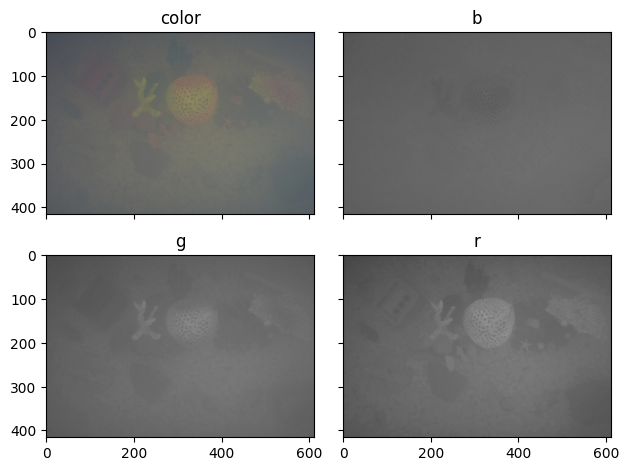

In [1]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
from dataclasses import dataclass

from pathlib import Path

from common import OrderedImage, FloatArray, Uint8Array
from plotting import plot_imgs, plot_img, plot_channels
from stepwise import StatType, MinMaxMean, Stats, load_img, color_loss, channel_correction, basic_CLAHE_float, basic_CLAHE_u8_cl

PATH = Path('milk') / 'a15.jpg'
# PATH = Path('lake') / 'blue_blur.png'

img = load_img(PATH)
plot_channels(img)

# B. Dynamic Turbid Color Correction

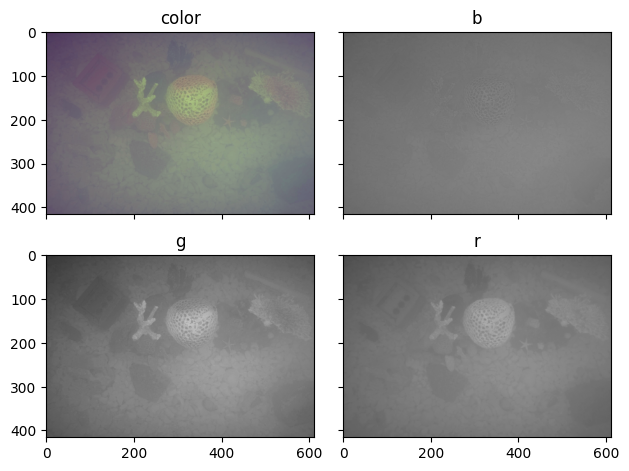

In [2]:
channel_correction(img)
plot_channels(img)

# C. Advanced De-Turbid Scene Model

## Using OpenCV (static clip limit)

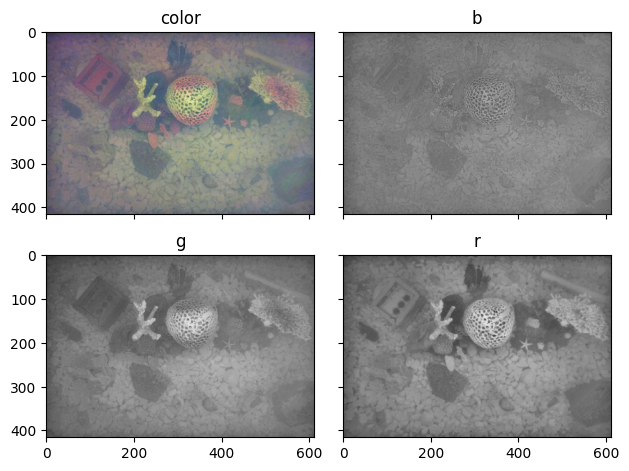

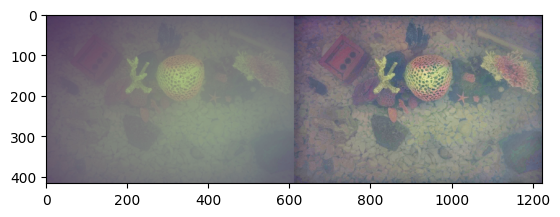

In [3]:
clahed1 = basic_CLAHE_float(img)
plot_channels(clahed1)
plot_img(np.hstack((img.cl, clahed1.cl)))

# TODO: rewrite CLAHE to have dynamic clip limit based on block turbidity estimation

## Dynamic Clip Limit

### Block Splitting

In [4]:
n = 64
padded_w_in_blocks = img.w // n + 1
padded_w = padded_w_in_blocks * n
padded_h_in_blocks = img.h // n + 1
padded_h = padded_h_in_blocks * n

img_before_padding = img.clone()

print(padded_w_in_blocks * padded_h_in_blocks)

padding_w = padded_w - img.w
padding_h = padded_h - img.h

print('unpadded', img.cf.shape)

channels: list[FloatArray] = []
for channel in img.cf:
    channels.append(cv2.copyMakeBorder(channel, 0, padding_h, 0, padding_w, cv2.BORDER_DEFAULT).astype(np.float32))

img.set_cl(cv2.merge(channels).astype(np.float32))

print('padded', img.cf.shape)

# plot_img(img)
# plot_img(basic_CLAHE_float(img))

blocks = []

for y in range(padded_h_in_blocks):
    for x in range(padded_w_in_blocks):
        blocks.append(
            OrderedImage(img.cl[y * n:y * n + n, x * n:x * n + n])
        )

# plot_imgs(blocks, max_cols=padded_w_in_blocks)

70
unpadded (3, 416, 612)
padded (3, 448, 640)


### Sobel

[0.5250378284277201, 0.5496562328068183, 0.5762077741590808, 0.6104520552581891, 0.6312512577353478, 0.6932236003465562, 0.7105906380187956, 0.7039593767984966, 0.6257619128866401, 0.5888601703864828, 0.5279261289997548, 0.6379322729873234, 0.6352848243840349, 1.236327441844852, 1.0188785850815982, 0.8344418937482885, 0.7667795842367544, 0.9134319023470119, 0.757607665809245, 0.7584452807371566, 0.581785040395274, 0.673172909089882, 0.7198818832759072, 0.8446130636652258, 0.6962728434122514, 0.49324062176636363, 0.8716064717611766, 0.966615884571117, 0.5815181175066381, 0.6388449921790571, 0.6444828988483565, 0.7543107527044384, 0.6748364716793184, 0.8241047443025652, 0.7988421181901404, 0.7120708066786016, 0.7058109483487679, 0.6259820588422994, 0.57845164884572, 0.6386895166847253, 0.6390412619062819, 0.6482518039213598, 0.6450363482930015, 0.8917262949915558, 0.6516828541692823, 0.5814589137141112, 0.6071149517172433, 0.5662361782339619, 0.6179432968265828, 0.6239638682075058, 0.584

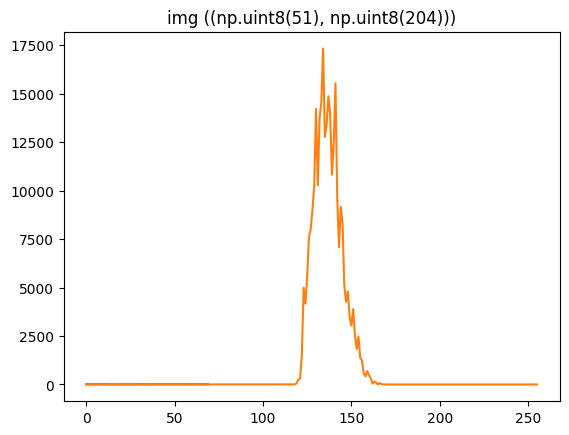

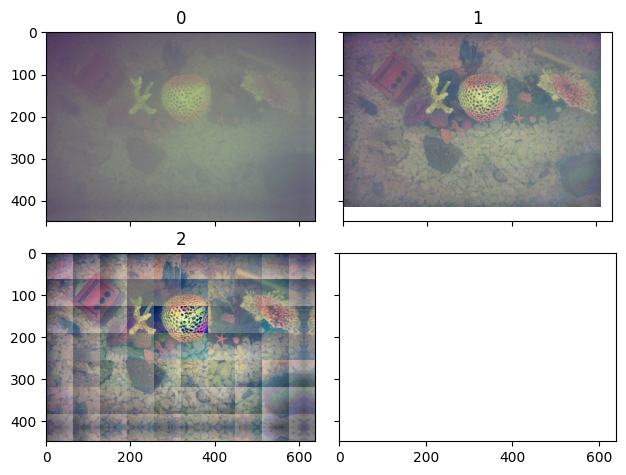

In [ ]:
def plot_hist(img_cl, title):
    plt.title(f'{title} ({img_cl.min(), img_cl.max()})')
    plt.plot(cv2.calcHist([(img_cl * 255).astype(np.uint8)], channels=[0], mask=None, histSize=[256], ranges=[0, 256]))
    plt.show()

SOBEL_BLUR_KERNEL_SIZE = 15
SOBEL_KERNEL_SIZE = (3, 3)

TURBIDITY_FACTOR_SOBEL_WEIGHT = 0.6  # w_1
TURBIDITY_FACTOR_SATURATION_WEIGHT = 1.0 - TURBIDITY_FACTOR_SOBEL_WEIGHT  # w_2

NUMERATOR_SAFETY = 1e-6

@dataclass
class MeanStdDev:
    mean: float
    std_dev: float

def sobel_mean_std_dev(img: OrderedImage[FloatArray]) -> MeanStdDev:
    gray = cv2.cvtColor(img.cl, cv2.COLOR_RGB2GRAY)

    # gray = cv2.GaussianBlur(gray, (SOBEL_BLUR_KERNEL_SIZE, SOBEL_BLUR_KERNEL_SIZE), 0)

    # Could use Scharr or Canny instead

    # ddepth is output precision
    # grad_sum = cv2.Sobel(gray, ddepth=cv2.CV_32F, dx=1, dy=1, ksize=SOBEL_KERNEL_SIZE[0])
    grad_x = cv2.Sobel(gray, ddepth=cv2.CV_32F, dx=1, dy=0, ksize=SOBEL_KERNEL_SIZE[0])

    # grad_y = cv2.Scharr(gray,ddepth,0,1)
    grad_y = cv2.Sobel(gray, ddepth=cv2.CV_32F, dx=0, dy=1, ksize=SOBEL_KERNEL_SIZE[1])

    # plot_imgs((grad_x, grad_y))

    # grad_x = cv2.convertScaleAbs(grad_x, alpha=1 / grad_x.max())
    # grad_y = cv2.convertScaleAbs(grad_y, alpha=1 / grad_y.max())

    grad_x = np.abs(grad_x / grad_x.max())
    grad_y = np.abs(grad_y / grad_y.max())

    grad_sum = cv2.addWeighted(grad_x, 0.5, grad_y, 0.5, 0)

    # show_hist(grad_sum, 'grad sum')

    # plt.imshow(gray, cmap='gray', vmin=0.0, vmax=1.0)
    # plt.show()

    # plt.imshow(grad_sum, cmap='gray', vmin=0.0, vmax=1.0)
    # plt.show()

    msd = cv2.meanStdDev(grad_sum)

    return MeanStdDev(msd[0].item(), msd[1].item())

def saturation_mean_std_dev(img: OrderedImage[FloatArray]) -> MeanStdDev:
    hsv = OrderedImage(cv2.cvtColor(img.cl, cv2.COLOR_BGR2HSV))
    msd = cv2.meanStdDev(hsv.cf[1])
    return MeanStdDev(msd[0].item(), msd[1].item())

def estimate_turbidity(img: OrderedImage[FloatArray]) -> float:
    sobel_msd = sobel_mean_std_dev(img)
    # print(sobel_msd)
    sat_msd = saturation_mean_std_dev(img)
    # print(sat_msd)

    weighted_sobel = TURBIDITY_FACTOR_SOBEL_WEIGHT * (sobel_msd.std_dev / (sobel_msd.mean + NUMERATOR_SAFETY))
    weighted_sat = TURBIDITY_FACTOR_SATURATION_WEIGHT * (sat_msd.std_dev / (sat_msd.mean + NUMERATOR_SAFETY))
    turbidity_estimate = weighted_sobel + weighted_sat

    # print(turbidity_estimate)

    return turbidity_estimate

turbidities = []
for block in blocks:
    turbidities.append(estimate_turbidity(block))

MAX_CLIP_LIMIT = 0.05 * 256  # OpenCV normalizes clip limit by dividing by max int value
                             # int((clipLimit / 256) * (block_width * block_height))
                             # We want to specify raw fraction, so multiply first
CLIP_LIMIT_SAFETY = 1e-6  # TODO: the highest turbidity block always uses this, seems wrong

clip_limits = []
for turbidity in turbidities:
    clip_limits.append(MAX_CLIP_LIMIT * (1 - (turbidity - min(turbidities)) / (max(turbidities) - min(turbidities))) + CLIP_LIMIT_SAFETY)

print(turbidities)
print(clip_limits)
plt.plot(clip_limits)

blocks_clahe = []
for i, (block, clip_limit) in enumerate(zip(blocks, clip_limits)):
    # print(clip_limit)
    clahed = basic_CLAHE_float(block, clip_limit=clip_limit, tileGridSize=(1, 1))
    # plot_img(clahed)
    blocks_clahe.append(clahed)

# plot_imgs(blocks, max_cols=padded_w_in_blocks)
# plot_imgs(blocks_clahe, max_cols=padded_w_in_blocks)

rows = []
for i in range(0, len(blocks_clahe), padded_w_in_blocks):
    rows.append(np.hstack([block.cl for block in blocks_clahe[i:i + padded_w_in_blocks]]))
clahed2: FloatArray = np.vstack(rows).astype(np.float32)

plot_hist((img.cl * 255).astype(np.uint8), 'img')
plot_imgs([img, clahed1, clahed2])

# plt.imshow(sobel(img), cmap='gray', vmin=0, vmax=255)
# plt.show()
# print(sobel(img))
# plt.hist(img.cf[0], bins=5)

In [ ]:
from clahe import adaptive_clahe

clip_limits = np.asarray(clip_limits)
clip_limits = np.reshape(clip_limits, shape=(padded_h_in_blocks, padded_w_in_blocks))

clahed3 = adaptive_clahe(img_before_padding, clip_limits, tile_size=n)

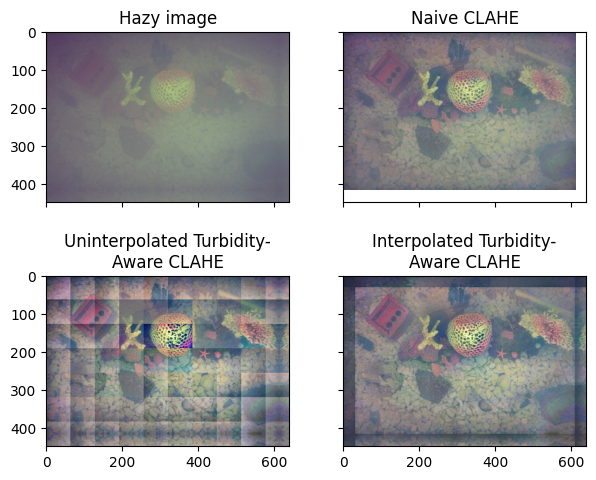

In [7]:
plot_imgs([img, clahed1, clahed2, clahed3], titles=['Hazy image', 'Naive CLAHE', 'Uninterpolated Turbidity-\nAware CLAHE', '\nInterpolated Turbidity-\nAware CLAHE'])